## Setup

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from functools import partial
import torch.nn as nn
import torchmetrics
import os
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils import data
import pandas as pd
from torch import Tensor
from torch.utils.data import DataLoader

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

## Fetch Data


_Download the Bach chorales dataset from https://homl.info/bach and unzip it. It is composed of 382 chorales composed by Johann Sebastian Bach. Each chorale is 100 to 640 time steps long, and each time step contains 4 integers, where each integer corresponds to a note's index on a piano (except for the value 0, which means that no note is played)._

In [3]:
from pathlib import Path
import tarfile
import urllib.request

def download_bach_chorales():
    bach_chorales_dir = Path("datasets/jsb_chorales")
    if not bach_chorales_dir.exists():
        tarball_path = Path("datasets/jsb_chorales.tgz")
        if not tarball_path.exists():
            Path("datasets").mkdir(parents=True, exist_ok=True)
            print("Downloading...", end="")
            urllib.request.urlretrieve("https://homl.info/bach", tarball_path)
            print("Done.")
        with tarfile.open(tarball_path) as housing_tarball:
            print("Decompressing...", end="")
            housing_tarball.extractall(path="datasets", filter="data")
            print("Done.")
    return bach_chorales_dir

bach_chorales_dir = download_bach_chorales()
bach_chorales_dir

PosixPath('datasets/jsb_chorales')

In [4]:
for i in range(10):
    path = bach_chorales_dir / f"train/chorale_00{i}.csv"
    df = pd.read_csv(path)
    print(f"{path}; length: {len(df)}")

df

datasets/jsb_chorales/train/chorale_000.csv; length: 192
datasets/jsb_chorales/train/chorale_001.csv; length: 228
datasets/jsb_chorales/train/chorale_002.csv; length: 208
datasets/jsb_chorales/train/chorale_003.csv; length: 432
datasets/jsb_chorales/train/chorale_004.csv; length: 260
datasets/jsb_chorales/train/chorale_005.csv; length: 212
datasets/jsb_chorales/train/chorale_006.csv; length: 292
datasets/jsb_chorales/train/chorale_007.csv; length: 180
datasets/jsb_chorales/train/chorale_008.csv; length: 132
datasets/jsb_chorales/train/chorale_009.csv; length: 192


,note0,note1,note2,note3
0,67,62,58,55
1,67,62,58,55
2,67,62,58,57
3,67,62,58,57
4,67,67,62,58
...,...,...,...,...
187,67,62,59,43
188,67,62,59,43
189,67,62,59,43
190,67,62,59,43


In [5]:
def read_chorales(bach_chorales_dir: Path, subfolder: str) -> list[Tensor]:
    chorales: list[Tensor] = []

    for chorale_csv in bach_chorales_dir.glob(f"{subfolder}/*.csv"):
        chorale_df = pd.read_csv(chorale_csv)
        chorale_tensor = torch.LongTensor(chorale_df.values)
        chorales.append(chorale_tensor)

    return chorales

chorales_train = read_chorales(bach_chorales_dir, "train")
chorales_valid = read_chorales(bach_chorales_dir, "valid")
chorales_test = read_chorales(bach_chorales_dir, "test")

# chorales_train.extend(chorales_test) # the suggestion to extend with more data

In [6]:
chorales_train[0]

tensor([[69, 64, 61, 45],
        [69, 64, 61, 45],
        [71, 64, 62, 45],
        [71, 64, 62, 45],
        [73, 69, 64, 57],
        [73, 69, 64, 57],
        [73, 69, 64, 56],
        [73, 69, 64, 56],
        [74, 69, 66, 54],
        [74, 69, 66, 54],
        [74, 69, 66, 54],
        [74, 69, 66, 54],
        [76, 68, 59, 52],
        [76, 68, 59, 52],
        [76, 68, 61, 52],
        [76, 68, 61, 52],
        [74, 66, 62, 47],
        [74, 66, 62, 47],
        [74, 68, 62, 47],
        [74, 68, 62, 47],
        [73, 69, 64, 49],
        [73, 69, 64, 49],
        [73, 69, 64, 50],
        [73, 69, 64, 50],
        [71, 68, 64, 52],
        [71, 68, 64, 52],
        [71, 68, 64, 52],
        [71, 68, 64, 52],
        [73, 69, 64, 45],
        [73, 69, 64, 45],
        [73, 69, 64, 45],
        [73, 69, 64, 45],
        [73, 64, 57, 57],
        [73, 64, 57, 57],
        [73, 64, 57, 56],
        [73, 64, 57, 56],
        [73, 66, 57, 54],
        [73, 66, 57, 54],
        [73,

In [7]:
chorales_train[0].shape

torch.Size([228, 4])

### Functions to listen to chorales

(Taken from [`13_processing_sequences_using_rnns_and_cnns.ipynb`](../13_processing_sequences_using_rnns_and_cnns.ipynb))

In [8]:
from IPython.display import Audio

def notes_to_frequencies(notes):
    # Frequency doubles when you go up one octave; there are 12 semi-tones
    # per octave; Note A on octave 4 is 440 Hz, and it is note number 69.
    return 2 ** ((notes - 69) / 12) * 440

def frequencies_to_samples(frequencies, tempo, sample_rate):
    note_duration = 60 / tempo # the tempo is measured in beats per minutes
    # To reduce click sound at every beat, we round the frequencies to try to
    # get the amplitude close to zero at the end of each note.
    frequencies = (note_duration * frequencies).round() / note_duration
    n_samples = int(note_duration * sample_rate)
    time = torch.linspace(0, note_duration, n_samples)
    sine_waves = torch.sin(2 * torch.pi * frequencies.reshape(-1, 1) * time)
    # Removing all notes with frequencies ≤ 9 Hz (includes note 0 = silence)
    sine_waves *= (frequencies > 9.).reshape(-1, 1)
    return sine_waves.reshape(-1)

def chords_to_samples(chords, tempo, sample_rate):
    freqs = notes_to_frequencies(chords)
    freqs = torch.cat([freqs, freqs[-1:]], dim=0) # make last note a bit longer
    merged = torch.stack([frequencies_to_samples(melody, tempo, sample_rate)
                          for melody in freqs.T]).mean(dim=0)
    n_fade_out_samples = sample_rate * 60 // tempo # fade out last note
    fade_out = torch.linspace(1., 0., n_fade_out_samples)**2
    merged[-n_fade_out_samples:] *= fade_out
    return merged

def play_chords(chords, tempo=160, amplitude=0.1, sample_rate=44100):
    samples = amplitude * chords_to_samples(chords, tempo, sample_rate)
    return display(Audio(samples, rate=sample_rate))

In [9]:
# for i in range(3):
#     play_chords(chorales_train[i])

### Converting into Pytorch tensors

So from the official solution we know that we don't want to predict the next 4 notes separately but we want to flatten the 4s into a 1d sequence and predict a 1D list of 4 elements.
This requires transforming the data

In [10]:
chorales_train[0].shape

torch.Size([228, 4])

In [11]:
chorales_train[0][:2, :]

tensor([[69, 64, 61, 45],
        [69, 64, 61, 45]])

In [12]:
chorales_train_0 = chorales_train[0].reshape(-1)
chorales_train_0.shape

torch.Size([912])

In [13]:
chorales_train_0[:2*4]

tensor([69, 64, 61, 45, 69, 64, 61, 45])

In [14]:
chorales_train_0.shape[0] % 4

0

In [15]:
num_unique_classes = set()

for tensor in chorales_train:
    for row in tensor:
        for value in row:
            num_unique_classes.add(value.item())

len(num_unique_classes)

47

Which ones?

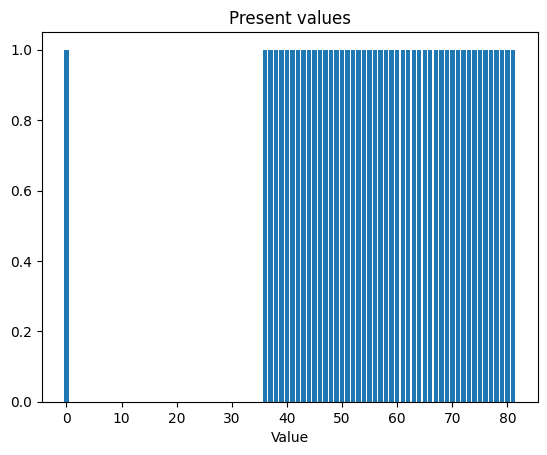

In [16]:
import matplotlib.pyplot as plt

all_vals = range(min(num_unique_classes), max(num_unique_classes) + 1)
present = [1 if v in num_unique_classes else 0 for v in all_vals]

plt.bar(all_vals, present)
plt.xlabel("Value")
plt.title("Present values")
plt.show()

So there's $47$ unique values. And we'll treat them as categorical values (because they are integers), which we will have to one-hot encode (based on the solution reference which I will follow along with here). 

We want to add a new unique value `1` to indicate **start-of-sequence** as in the official solution. So that gives us $48$ total unique values.

So we'll shift the regular values down to `2-47` as in the instructions

In [17]:
min(num_unique_classes - {0})

36

In [18]:
NUM_CLASSES = 48

In [19]:
WINDOW_LENGTH = 128

In [20]:
import torch.nn.functional as F

class ChoraleDataset(torch.utils.data.Dataset):

    SOS = torch.tensor([1])
    TOTAL_CLASSES = 36
    SPECIAL_CATEGORIES = 2 # "nothing = 0" and "start-of-sequence" = 1

    def __init__(self, chorales: list[Tensor], window_length: int):
        self.chorales = chorales
        self.windows = ChoraleDataset._create_windows(chorales, window_length)
        """
        [<sequence window>, <original value>]
        """

    @staticmethod
    def _prepare_for_preprocessing(notes: Tensor) -> Tensor:
        # shift everything left by
        offset = ChoraleDataset.TOTAL_CLASSES - ChoraleDataset.SPECIAL_CATEGORIES
        # Each note (other than 0 and 1) is shifted left to fill the "spots" (2, 3, ... 47)
        # (relu just used here to prevent 0s from becoming negative due to the shift)
        note_indices = torch.cat([ChoraleDataset.SOS, F.relu(notes - offset)])

        return note_indices


    @staticmethod
    def _create_windows(chorales: list[Tensor], window_length: int) -> list[tuple[Tensor, Tensor]]:

        windows: list[tuple[Tensor, Tensor]] = []

        for chorale in chorales:
            notes = chorale.reshape(-1) # flattern them

            note_indices = ChoraleDataset._prepare_for_preprocessing(notes)

            X = ChoraleDataset._preprocess_note_indices(note_indices)

            #                    👇 that's how many starting point loops we can have.
            for index in range(len(notes) - window_length):

                windows.append((
                    # this is the sequence window
                    X[index: index + window_length],
                    # the actual original value
                    note_indices[index + 1 : index + window_length + 1]
                ))

        return windows

    @staticmethod
    def _preprocess_note_indices(note_indices: Tensor, length: int|None = None) -> Tensor:
        # one-hot encode the presence/absence of every int category (0-47) for every categorical int (note)
        # (one note becomes a vector of 0.0 and 1.0 depending on presence/absence)
        notes_one_hot = F.one_hot(note_indices, num_classes=NUM_CLASSES).to(torch.float32)
        # basically this gives us tensors like so:
        # from: [1, 0, 46]
        # to:   [[0.0, 1.0, 0.0, ...], [1.0, 0.0, ..., 0.0], [0.0, ... , 1.0, 0.0]]

        if length is None:
            length = len(note_indices) # (note that we appended `1` to the start of the tensor!)

        # gets a 1D list of indices, e.g.:
        #       tensor([0., 1., 2., 3., 4.])
        #
        # then `.view(-1, 1)` batches them up to be 2D of 1 item in the 2nd dimension:
        #       tensor([[0.], [1.], [2.], [3.], [4.]])
        #
        # then shift every index by one (recalling that we appended `1` at the start of the tensor!), e.g.:
        #       tensor([[-1.], [0.], [1.], [2.], [3.]])
        indx = torch.arange(
            len(note_indices),
            dtype=torch.float32,
            device=note_indices.device
        ).view(-1, 1) - 1

        # now we concat them all to get (per note):
        # [
        #   [
        #       0.0, 1.0, 0.0, ... 0.0,     (<- the one_hot encoded categorical of the note)
        #       3.0,                        (<- note index within each chord)
        #       1.0,                        (<- chord index modulo 4 - likely to be most useful when time signature is 4/4)
        #       0.8750                      (<- progress percentage within each chorale - lets us control the length of each generated chorale)
        #   ],
        #   ...
        # ]
        return torch.cat([
            notes_one_hot,
            indx % 4,
            indx % 16 // 4,
            indx / (length - 1)
        ], dim=-1)


    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):
        return self.windows[index]


Investigating some sample cases on the outputs...

In [21]:
tmp_indx = torch.arange(5, dtype=torch.float32)
print(tmp_indx)
print()

tmp_indx = tmp_indx.view(-1, 1)
print(tmp_indx)
print()

tmp_indx = tmp_indx - 1
print(tmp_indx)

tensor([0., 1., 2., 3., 4.])

tensor([[0.],
        [1.],
        [2.],
        [3.],
        [4.]])

tensor([[-1.],
        [ 0.],
        [ 1.],
        [ 2.],
        [ 3.]])


In [22]:
tmp_note_indices = torch.LongTensor([
    1, # start-of-sequence
    4, 5, 9, 20, # time=0
    3, 5, 33, 9 # time=1
])
print(tmp_note_indices)
print()


tmp_notes_one_hot = F.one_hot(tmp_note_indices, num_classes=NUM_CLASSES).to(torch.float32)
print(tmp_notes_one_hot)
print()


tmp_length = len(tmp_note_indices)
print(tmp_length)
print()

tmp_indx = torch.arange(
    len(tmp_note_indices),
    dtype=torch.float32,
    device=tmp_note_indices.device
).view(-1, 1) - 1
print(tmp_indx)
print()

print(tmp_indx % 4) # note index within each chord
print()

print(tmp_indx % 16 // 4) # chord index within every chorale
print()

print(tmp_indx / (tmp_length - 1)) # progress "percentage" within each chorale
print()

# Concatted in a flattened list
tmp_concat = torch.cat([
    tmp_notes_one_hot,
    tmp_indx % 4,
    tmp_indx % 16 // 4,
    tmp_indx / (tmp_length - 1)
], dim=-1)
print(tmp_concat)
print()


tensor([ 1,  4,  5,  9, 20,  3,  5, 33,  9])

tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [23]:
torch.manual_seed(42)

BATCH_SIZE = 32 * 32
NUM_WORKERS = 2

train_set = ChoraleDataset(chorales_train, WINDOW_LENGTH)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, shuffle=True)

valid_set = ChoraleDataset(chorales_valid, WINDOW_LENGTH)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

test_set = ChoraleDataset(chorales_test, WINDOW_LENGTH)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

In [24]:
BATCH_SIZE

1024

In [25]:
WINDOW_LENGTH

128

In [26]:
X, y = train_set[0]
X.shape, y.shape

(torch.Size([128, 51]), torch.Size([128]))

In [27]:
N_INPUT_FEATURES = X.shape[1]

In [28]:
window: Tensor
target: Tensor
for window, target in train_loader:
    print("==============")
    print("WINDOW")
    #print(window)
    print(window.shape)
    print(window[0])
    print("TARGET")
    #print(target)
    print(target.shape)
    print(target[0])
    print("==============")
    break


WINDOW
torch.Size([1024, 128, 51])
tensor([[0.0000, 0.0000, 0.0000,  ..., 3.0000, 3.0000, 0.2908],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.2917],
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.2925],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 3.0000, 0.3993],
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 3.0000, 0.4002],
        [0.0000, 0.0000, 0.0000,  ..., 2.0000, 3.0000, 0.4010]])
TARGET
torch.Size([1024, 128])
tensor([36, 31, 28, 12, 36, 31, 28, 12, 36, 31, 28, 12, 36, 31, 28, 12, 36, 31,
        28, 12, 36, 31, 28, 12, 36, 31, 28, 12, 36, 31, 28, 12, 36, 31, 28, 12,
        36, 31, 28, 12, 36, 31, 28, 12, 36, 31, 28, 12, 35, 32, 28, 16, 35, 32,
        28, 16, 35, 32, 28, 16, 35, 32, 28, 16, 35, 32, 28, 14, 35, 32, 28, 14,
        35, 32, 28, 14, 35, 32, 28, 14, 36, 33, 28, 12, 36, 33, 28, 12, 36, 33,
        28, 12, 36, 33, 28, 12, 38, 33, 29, 11, 38, 33, 29, 11, 38, 33, 29, 11,
        38, 33, 29, 11, 38, 32, 29,  9, 38, 32, 29,  9, 

> _Train a model—recurrent, convolutional, or both—that can predict the next time step (four notes), given a sequence of time steps from a chorale._

# Train

I would actually like to follow along with the official solution here as well since I think it is distinct enough to investigate deeply.

In [29]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.pad, dilation=dilation, **kwargs)

    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out


class BachModel(nn.Module):
    def __init__(self,
                 n_inputs: int = N_INPUT_FEATURES,
                 conv_dim: int = 32, # hyperparameter
                 lstm_dim: int = 64, # hyperparameter
                 n_notes: int = NUM_CLASSES
                 ):
        super().__init__()

        # Similar to the general concept of the WaveNet model
        conv_layers = []
        for idx in range(4):
            conv_layers += [
                CausalConv1d(n_inputs, conv_dim, kernel_size=2, dilation=2**idx),
                nn.ReLU(),
                nn.BatchNorm1d(conv_dim),
            ]
            n_inputs = conv_dim

        self.conv_stack = nn.Sequential(*conv_layers)

        self.lstm = nn.LSTM(
            input_size=conv_dim,
            hidden_size=lstm_dim,
            batch_first=True
        )

        self.output = nn.Linear(lstm_dim, n_notes) # this is going to output logits.

        # Though, we're not doing regression here but classification, essentually.

    def forward(self,
                X: Tensor  # [batch, window_length, features]
                ) -> Tensor:
        # See the WaveNet discussion, we have to permute it as follows to match up the shapes...
        Z = X.transpose(1, 2)
        Z = self.conv_stack(Z)
        Z = Z.transpose(1, 2)
        # /end

        # RNN layer
        Z, last_state = self.lstm(Z)

        # logits/classification layer
        Z = self.output(Z) # out shape: [batch_size, window_size (e.g. 128), logits (e.g 48)]

        # this one is to match up the shape for the xentrophy loss function!
        ret = Z.transpose(1, 2) # shape: [batch_size, logits (e.g 48), window_size (e.g. 128)]

        return ret

In [30]:
tmp_tensor = torch.FloatTensor([
    [
        [1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
    ],
    [
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
    ],
])
print(tmp_tensor)

tmp_tensor.transpose(1, 2)

tensor([[[1., 1., 1., 1.],
         [2., 2., 2., 2.],
         [3., 3., 3., 3.]],

        [[4., 4., 4., 4.],
         [5., 5., 5., 5.],
         [6., 6., 6., 6.]]])


tensor([[[1., 2., 3.],
         [1., 2., 3.],
         [1., 2., 3.],
         [1., 2., 3.]],

        [[4., 5., 6.],
         [4., 5., 6.],
         [4., 5., 6.],
         [4., 5., 6.]]])

Initialise and train it

In [31]:
torch.manual_seed(42)
bach_model = BachModel().to(device)

In [32]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device) # y_batch is shape:
            #   [batch_size (e.g. 32), window_size (e.g. 128)]

            y_pred = model(X_batch) # in this particular case shape is:
            #   [batch_size (e.g. 32), logits (e.g. 48), window_size (e.g. 128)]
            loss = loss_fn(y_pred, y_batch)

            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [33]:
torch.manual_seed(42)

optimizer = torch.optim.NAdam(
    bach_model.parameters(),
    lr=1e-3
)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=NUM_CLASSES
).to(device)

In [34]:
torch.manual_seed(42)

history = train(
    bach_model,
    optimizer,
    criterion,
    accuracy,
    train_loader,
    valid_loader,
    n_epochs=20
)

history

Epoch 1/20, train loss: 1.8909, train metric: 0.5448, valid metric: 0.7789
Epoch 2/20, train loss: 0.7508, train metric: 0.8088, valid metric: 0.8107
Epoch 3/20, train loss: 0.6301, train metric: 0.8265, valid metric: 0.8164
Epoch 4/20, train loss: 0.5835, train metric: 0.8341, valid metric: 0.8205
Epoch 5/20, train loss: 0.5553, train metric: 0.8391, valid metric: 0.8239
Epoch 6/20, train loss: 0.5335, train metric: 0.8435, valid metric: 0.8211
Epoch 7/20, train loss: 0.5162, train metric: 0.8471, valid metric: 0.8261
Epoch 8/20, train loss: 0.5024, train metric: 0.8502, valid metric: 0.8235
Epoch 9/20, train loss: 0.4897, train metric: 0.8530, valid metric: 0.8265
Epoch 10/20, train loss: 0.4780, train metric: 0.8558, valid metric: 0.8288
Epoch 11/20, train loss: 0.4678, train metric: 0.8583, valid metric: 0.8258
Epoch 12/20, train loss: 0.4582, train metric: 0.8606, valid metric: 0.8236
Epoch 13/20, train loss: 0.4462, train metric: 0.8644, valid metric: 0.8301
Epoch 14/20, train lo

{'train_losses': [1.8909447237532189,
  0.7507592515742525,
  0.6301156260231708,
  0.5834681883137277,
  0.5552743660642746,
  0.5335336267314059,
  0.5162245082728406,
  0.50235894782112,
  0.4897088414811073,
  0.478042408823967,
  0.46778912905682907,
  0.4581511353558682,
  0.44620081401885825,
  0.4442509227293603,
  0.44311997278573667,
  0.4419044349738892,
  0.4408307020017441,
  0.4395342749801088,
  0.4382294143768067,
  0.43684882527970254],
 'train_metrics': [0.5448444485664368,
  0.8088460564613342,
  0.8264645338058472,
  0.8340815901756287,
  0.8391063809394836,
  0.8434799909591675,
  0.8470736742019653,
  0.8501573801040649,
  0.8529707193374634,
  0.8557783365249634,
  0.8582665920257568,
  0.8606177568435669,
  0.8644496202468872,
  0.864984929561615,
  0.8652713894844055,
  0.8656119704246521,
  0.8658964037895203,
  0.8661983609199524,
  0.8664941787719727,
  0.8668570518493652],
 'valid_metrics': [0.7788987159729004,
  0.8107000589370728,
  0.8163716793060303,
  

In [35]:
evaluate_tm(bach_model, test_loader, accuracy)

tensor(0.8244, device='cuda:0')

Try generating some music with it

In [ ]:
def generate_chorale(model: BachModel, seed_chords: Tensor, num_chords: int) -> Tensor:
    target_length: int = (num_chords * 4) + 1

    notes: Tensor = seed_chords.reshape(-1) # flatten them
    note_indices: Tensor = ChoraleDataset._prepare_for_preprocessing(notes).to(device) # flattened, sos-prefixed view

    while len(note_indices) < target_length:
        X: Tensor = ChoraleDataset._preprocess_note_indices(note_indices, target_length)

        with torch.no_grad():
            new_note_logits = model(X.unsqueeze(0)) # because this is the expected shape, take it from shape [<time steps>, <features>] to [1, <time steps>, <features>]

        #                                [<first (aka only) prediction>, <all logits>, <only the last (aka predicted) note>]
        new_note_index: Tensor = new_note_logits[0, :, -1].argmax(keepdim=True) # and then just take the max-valued logit.
        print("new_note_index")
        print(new_note_index.shape)
        print(new_note_index)

        note_indices = torch.cat([note_indices, new_note_index])

        print(f"\r{len(note_indices) / target_length:.1%}", end="")

    notes = note_indices.where(
        note_indices < 2, # the `0` notes and the `1` sos note stays as it is from note_indices
        note_indices + (ChoraleDataset.TOTAL_CLASSES - ChoraleDataset.SPECIAL_CATEGORIES) # the rest are put to the right values
    )

    # cut off the SoS and then reshape it to be batched in sets of 4 for every timestamp again, like the input dataset.
    return notes[1:].reshape(-1, 4)



In [53]:
SEED_IDX = 8
SEED_LENGTH = 8
NR_GENERATE = 128

In [ ]:
seed_chords = chorales_valid[SEED_IDX][:SEED_LENGTH]
seed_chords

tensor([[71, 64, 55, 52],
        [71, 64, 55, 52],
        [71, 64, 55, 52],
        [71, 64, 55, 52],
        [67, 64, 59, 52],
        [67, 64, 59, 52]])

Generate 56 more chords as in the official solution:

In [47]:
torch.manual_seed(42)
chorale = generate_chorale(bach_model, seed_chords, 8 + 56).cpu()

new_note_index
torch.Size([1])
tensor([33], device='cuda:0')
10.1%new_note_index
torch.Size([1])
tensor([30], device='cuda:0')
10.5%new_note_index
torch.Size([1])
tensor([25], device='cuda:0')
10.9%new_note_index
torch.Size([1])
tensor([16], device='cuda:0')
11.3%new_note_index
torch.Size([1])
tensor([33], device='cuda:0')
11.7%new_note_index
torch.Size([1])
tensor([30], device='cuda:0')
12.1%new_note_index
torch.Size([1])
tensor([25], device='cuda:0')
12.5%new_note_index
torch.Size([1])
tensor([16], device='cuda:0')
12.8%new_note_index
torch.Size([1])
tensor([35], device='cuda:0')
13.2%new_note_index
torch.Size([1])
tensor([30], device='cuda:0')
13.6%new_note_index
torch.Size([1])
tensor([26], device='cuda:0')
14.0%new_note_index
torch.Size([1])
tensor([14], device='cuda:0')
14.4%new_note_index
torch.Size([1])
tensor([35], device='cuda:0')
14.8%new_note_index
torch.Size([1])
tensor([30], device='cuda:0')
15.2%new_note_index
torch.Size([1])
tensor([26], device='cuda:0')
15.6%new_note_i

In [48]:
chorale

tensor([[71, 64, 55, 52],
        [71, 64, 55, 52],
        [71, 64, 55, 52],
        [71, 64, 55, 52],
        [67, 64, 59, 52],
        [67, 64, 59, 52],
        [67, 64, 59, 50],
        [67, 64, 59, 50],
        [69, 64, 60, 48],
        [69, 64, 60, 48],
        [69, 64, 60, 48],
        [69, 64, 60, 48],
        [71, 63, 54, 47],
        [71, 63, 54, 47],
        [71, 63, 54, 47],
        [71, 63, 54, 47],
        [71, 64, 55, 52],
        [71, 64, 55, 52],
        [71, 64, 57, 54],
        [71, 64, 57, 54],
        [71, 62, 59, 55],
        [71, 62, 59, 55],
        [71, 62, 59, 55],
        [71, 62, 59, 55],
        [72, 64, 60, 57],
        [72, 64, 60, 57],
        [72, 64, 60, 57],
        [72, 64, 60, 57],
        [74, 69, 59, 53],
        [74, 69, 59, 53],
        [74, 69, 59, 53],
        [74, 69, 59, 53],
        [72, 67, 60, 52],
        [72, 67, 60, 52],
        [72, 67, 60, 52],
        [72, 67, 60, 52],
        [71, 67, 62, 50],
        [71, 67, 62, 50],
        [71,

In [ ]:
play_chords(chorale)

Following along with the official solution of making it less "predictable"

In [50]:
def generate_chorale_v2(
        model: BachModel,
        seed_chords: Tensor,
        num_chords: int,
        temperature: float = 1.0
        ) -> Tensor:
    target_length: int = (num_chords * 4) + 1

    notes: Tensor = seed_chords.reshape(-1) # flatten them
    note_indices: Tensor = ChoraleDataset._prepare_for_preprocessing(notes).to(device) # flattened, sos-prefixed view

    while len(note_indices) < target_length:
        X: Tensor = ChoraleDataset._preprocess_note_indices(note_indices, target_length)

        with torch.no_grad():
            new_note_logits = model(X.unsqueeze(0)) # because this is the expected shape, take it from shape [<time steps>, <features>] to [1, <time steps>, <features>]


        # when `temperature` is high (approaches 1.0) it will bring the predicted probabilities closer together,
        # reducing the probability of the linkely notes and increasing the probability of unlikely ones.
        # then convert the logits to probabilities given the softmax fn
        new_note_probas = F.softmax(new_note_logits[0, :, -1] / temperature, dim=0)

        # use F.multinomial() function to sample the new note index using these probabilities
        new_note_index: Tensor = torch.multinomial(new_note_probas, num_samples=1)

        print("new_note_index")
        print(new_note_index.shape)
        print(new_note_index)

        note_indices = torch.cat([note_indices, new_note_index])

        print(f"\r{len(note_indices) / target_length:.1%}", end="")

    notes = note_indices.where(
        note_indices < 2, # the `0` notes and the `1` sos note stays as it is from note_indices
        note_indices + (ChoraleDataset.TOTAL_CLASSES - ChoraleDataset.SPECIAL_CATEGORIES) # the rest are put to the right values
    )

    # cut off the SoS and then reshape it to be batched in sets of 4 for every timestamp again, like the input dataset.
    return notes[1:].reshape(-1, 4)



Following along to try and generate some interesting ones!

In [ ]:
seed_chords = chorales_valid[SEED_IDX][:SEED_LENGTH]
generated_chorales: dict[float, Tensor] = {}

for temperature in (0.6, 1.0, 1.1):
    torch.manual_seed(42)

    print("Temperature:", temperature)
    chorale = generate_chorale_v2(bach_model, seed_chords, NR_GENERATE, temperature).cpu()
    generated_chorales[temperature] = chorale

    play_chords(chorale)


What even was my original one?

In [ ]:
play_chords(chorales_valid[3])